In [ ]:
from google.colab import files
uploaded = files.upload()

Saving fusers.csv to fusers.csv


Dataset Loaded Successfully!

Columns:
 Index(['id', 'name', 'screen_name', 'fav_number', 'statuses_count',
       'followers_count', 'friends_count', 'favourites_count', 'listed_count',
       'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile',
       'default_profile_image', 'geo_enabled', 'profile_image_url',
       'profile_banner_url', 'profile_use_background_image',
       'profile_background_image_url_https', 'profile_text_color',
       'profile_image_url_https', 'profile_sidebar_border_color',
       'profile_background_tile', 'profile_sidebar_fill_color',
       'profile_background_image_url', 'profile_background_color',
       'profile_link_color', 'utc_offset', 'protected', 'verified',
       'description', 'updated', 'dataset'],
      dtype='object')

Class Distribution:
fake
0    902
1    435
Name: count, dtype: int64

Model Accuracy: 97.76%

Confusion Matrix:
 [[175   6]
 [  0  87]]


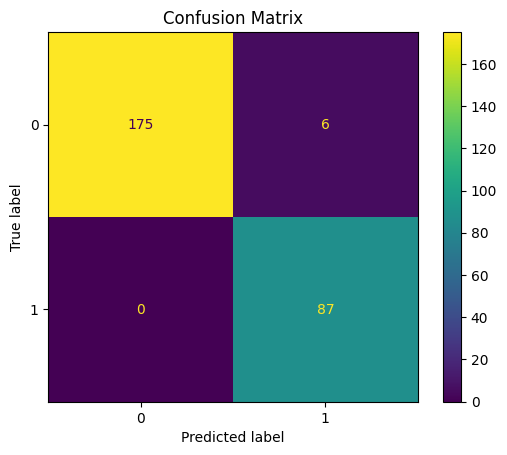


ROC AUC Score: 1.00


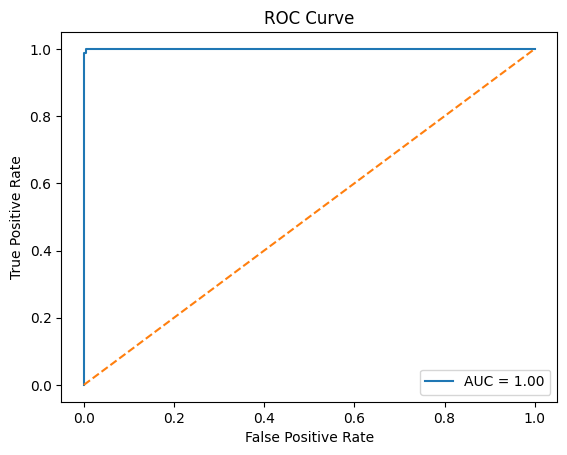


Enter Profile Details:

Followers count: 900
Following count: 48
Statuses count: 668
Favourites count: 27
Listed count: 92
Verified (1/0): 1
Default profile (1/0): 1
Default profile image (1/0): 1

🚨 Result: FAKE Profile
Confidence: 100.00%

--- Analysis ---
- Default profile image (suspicious)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# -------------------------------
# LOAD DATASET
# -------------------------------
data = pd.read_csv("fusers.csv")

print("Dataset Loaded Successfully!")
print("\nColumns:\n", data.columns)

# -------------------------------
# SELECT IMPORTANT FEATURES
# -------------------------------
data = data[[
    'followers_count',
    'friends_count',
    'statuses_count',
    'favourites_count',
    'listed_count',
    'verified',
    'default_profile',
    'default_profile_image'
]]

# -------------------------------
# HANDLE MISSING VALUES
# -------------------------------
data = data.fillna(0)

# -------------------------------
# FEATURE ENGINEERING
# -------------------------------
data['ratio'] = np.log1p(data['followers_count']) - np.log1p(data['friends_count'])
data['engagement'] = data['favourites_count'] / (data['statuses_count'] + 1)
data['activity'] = data['statuses_count'] / (data['friends_count'] + 1)

# -------------------------------
# CREATE TARGET COLUMN (FIXED)
# -------------------------------
data['fake'] = (
    (
        (data['followers_count'] < 150) &
        (data['friends_count'] > 500)
    ) |
    (
        (data['default_profile_image'] == 1) &
        (data['statuses_count'] < 30)
    )
).astype(int)

# -------------------------------
# CHECK CLASS DISTRIBUTION
# -------------------------------
print("\nClass Distribution:")
print(data['fake'].value_counts())

# SAFETY CHECK
if len(data['fake'].unique()) < 2:
    print(" Error: Only one class found. Adjust your condition.")
    exit()

# -------------------------------
# SPLIT DATA
# -------------------------------
X = data.drop('fake', axis=1)
y = data['fake']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# SCALING
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# MODEL
# -------------------------------
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

# -------------------------------
# PREDICTIONS
# -------------------------------
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("\n====================================")
print(f"Model Accuracy: {accuracy*100:.2f}%")
print("====================================")

# -------------------------------
# CONFUSION MATRIX
# -------------------------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# ROC CURVE
# -------------------------------
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(f"\nROC AUC Score: {roc_auc:.2f}")

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# -------------------------------
# USER INPUT
# -------------------------------
print("\nEnter Profile Details:\n")

followers = int(input("Followers count: "))
following = int(input("Following count: "))
posts = int(input("Statuses count: "))
favourites = int(input("Favourites count: "))
listed = int(input("Listed count: "))
verified = int(input("Verified (1/0): "))
default_profile = int(input("Default profile (1/0): "))
default_profile_image = int(input("Default profile image (1/0): "))

# FEATURE ENGINEERING FOR INPUT
ratio = np.log1p(followers) - np.log1p(following)
engagement = favourites / (posts + 1)
activity = posts / (following + 1)

# -------------------------------
# INPUT DATA
# -------------------------------
input_data = pd.DataFrame([{
    'followers_count': followers,
    'friends_count': following,
    'statuses_count': posts,
    'favourites_count': favourites,
    'listed_count': listed,
    'verified': verified,
    'default_profile': default_profile,
    'default_profile_image': default_profile_image,
    'ratio': ratio,
    'engagement': engagement,
    'activity': activity
}])

input_data = scaler.transform(input_data)

# -------------------------------
# PREDICTION
# -------------------------------
prediction = model.predict(input_data)[0]
probability = model.predict_proba(input_data)[0]

print("\n====================================")
if prediction == 1:
    print("🚨 Result: FAKE Profile")
else:
    print("✅ Result: REAL Profile")

print(f"Confidence: {max(probability)*100:.2f}%")
print("====================================")

# -------------------------------
# ANALYSIS
# -------------------------------
print("\n--- Analysis ---")
if followers < 150:
    print("- Low followers")
if following > 500:
    print("- High following")
if posts < 30:
    print("- Low activity")
if default_profile_image == 1:
    print("- Default profile image (suspicious)")
if verified == 0:
    print("- Not verified")